In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample 
import utils as u

In [2]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

### MAR

In [3]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [4]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [5]:
sourceData='/bettik/amoryc/MARout/GRf/spin2/work/'
variable='TT' 

fileNameF='mon-'+variable+'-MARv3.14_ER5-2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ATMLAY=1).TT.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

### ERA5-land

In [6]:
# ERA5-Land data coverage is only 2000 - 2023
folder_era5land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

(61, 121)


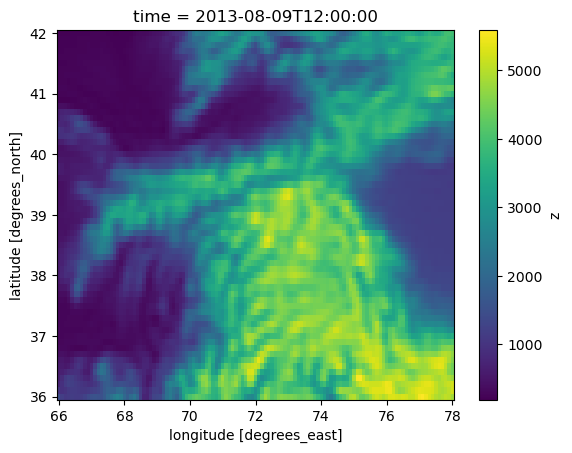

In [7]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
print(orog_era5land.shape)
orog_era5land[:,:].plot()

### ERA5

In [8]:
# ERA5 data coverage is only 2000 - 2023
folder_era5='/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'
tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

(25, 49)


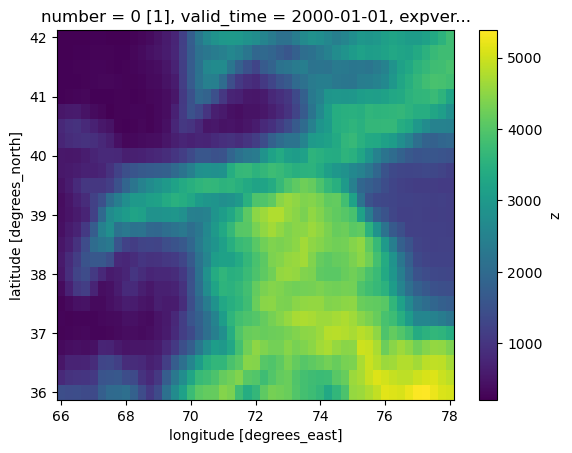

In [9]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5.shape)
orog_era5[:,:].plot()

### CRU

In [10]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

## MAR vs ERA5-Land

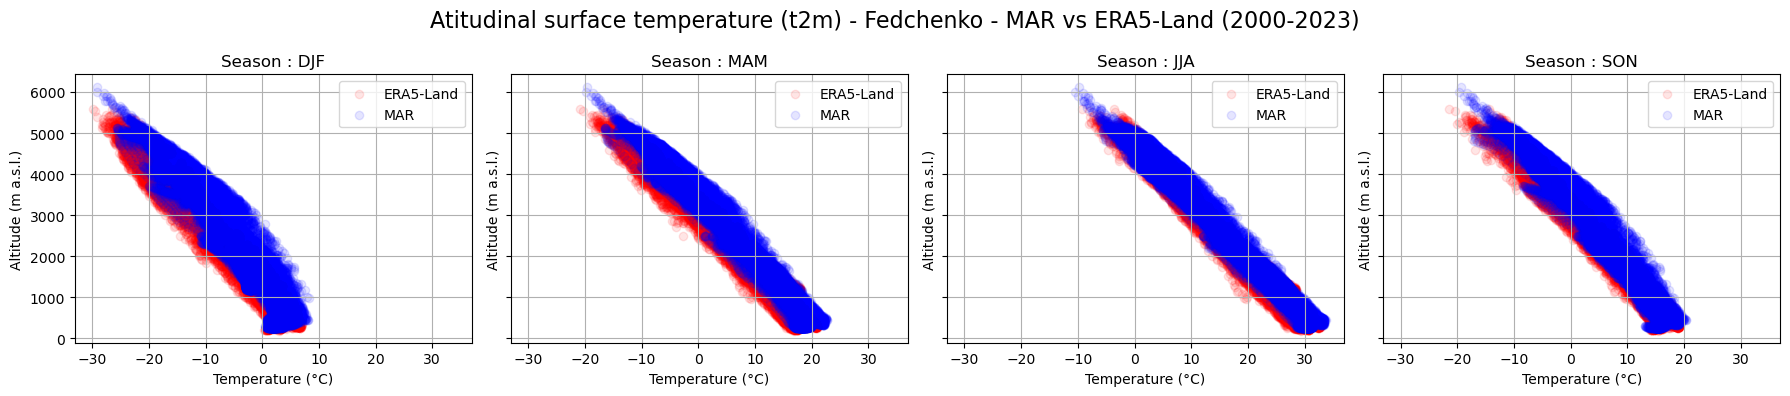

In [11]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(18, 4)) 
axs = axs.flatten() 

for i in range(4):
    ax = axs[i]
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5land=tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5land_flat = temp_era5land.reshape(-1) 

    SH_mar=ds_grF.SH.values.flatten()
    SH_era5land=orog_era5land.values.reshape(-1)

    ax.scatter(temp_era5land_flat, SH_era5land, color='red', label ='ERA5-Land',alpha=0.1)
    ax.scatter(temp_mar_flat, SH_mar, color='blue', label ='MAR',alpha=0.1)
    
    ax.set_title(f"Season : {season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) - Fedchenko - MAR vs ERA5-Land (2000-2023)', fontsize=16)

# plt.savefig("Alti_profiles_raw_MAR_ERA5_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

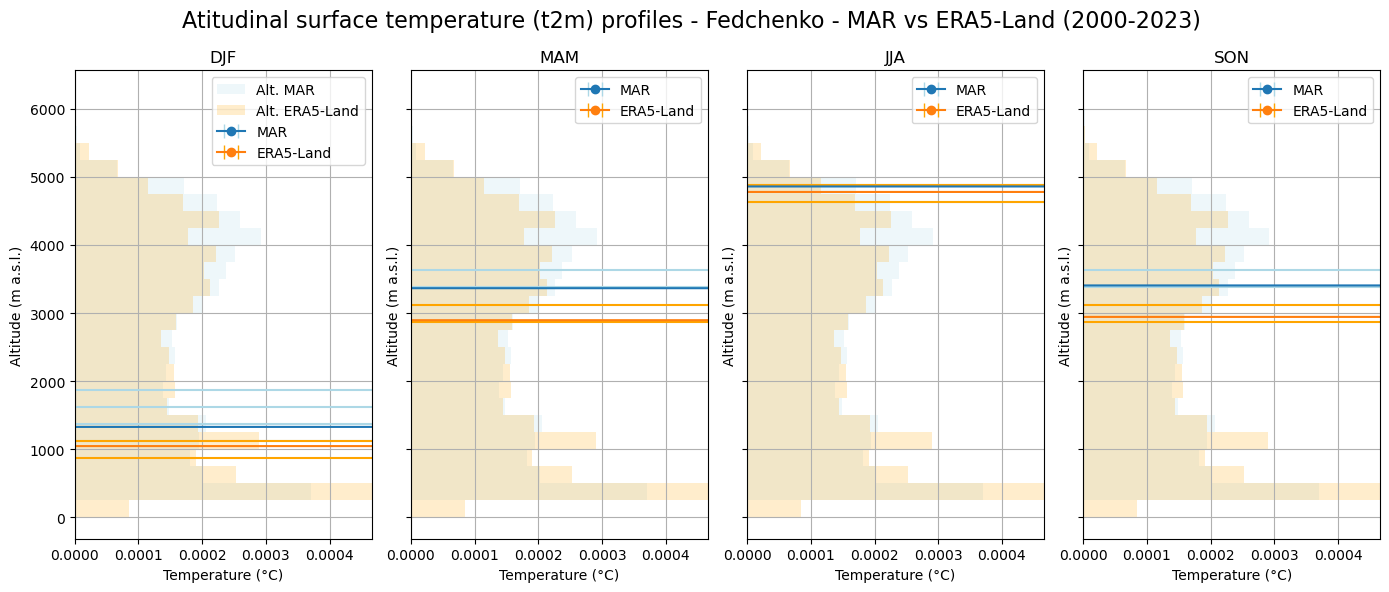

In [17]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(14, 6)) 
axs = axs.flatten() 

SH_mar=ds_grF.SH.values.flatten()
SH_era5land=orog_era5land.values.reshape(-1)

hist_mar, _ = np.histogram(SH_mar, bins=bins_mar, density=True)
hist_era5, _ = np.histogram(SH_era5land, bins=bins_era5land, density=True)
dens_max = max(hist_mar.max(), hist_era5.max()) * 1.2

for i in range(4):
    alt_min_mar = int(np.floor(SH_mar.min() / 250) * 250)
    alt_max_mar = int(np.ceil(SH_mar.max() / 250) * 250) 
    bins_mar = np.arange(alt_min_mar, alt_max_mar + 250, 250)
    means_mar = []
    stds_mar = []
    stds_SHmar = []
    bin_centers_mar = []

    alt_min_era5land = int(np.floor(SH_era5land.min() / 250) * 250)
    alt_max_era5land = int(np.ceil(SH_era5land.max() / 250) * 250)     
    bins_era5land = np.arange(alt_min_era5land, alt_max_era5land + 250, 250)
    means_era5land = []
    stds_era5land = []
    stds_SHera5land = []
    bin_centers_era5land = []
    
    ax = axs[i]
    
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5land=tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5land_flat = temp_era5land.reshape(-1)


    for j in range(len(bins_mar) - 1):
        mask_mar = (SH_mar >= bins_mar[j]) & (SH_mar < bins_mar[j + 1])
        temp_mar_in_bin = temp_mar_flat[mask_mar]
        SH_mar_in_bin = SH_mar[mask_mar]
        
        if len(temp_mar_in_bin) > 0:
            means_mar.append(np.mean(temp_mar_in_bin))
            stds_mar.append(np.std(temp_mar_in_bin))
            stds_SHmar.append(np.std(SH_mar_in_bin))
            bin_centers_mar.append((bins_mar[j] + bins_mar[j + 1]) / 2)

    for k in range(len(bins_era5land) - 1):
        mask_era5land = (SH_era5land >= bins_era5land[k]) & (SH_era5land < bins_era5land[k + 1])
        temp_era5land_in_bin = temp_era5land_flat[mask_era5land]    
        SH_era5land_in_bin = SH_era5land[mask_era5land]
        
        if len(temp_era5land_in_bin) > 0:
            means_era5land.append(np.mean(temp_era5land_in_bin))
            stds_era5land.append(np.std( temp_era5land_in_bin))
            stds_SHera5land.append(np.std(SH_era5land_in_bin))
            bin_centers_era5land.append((bins_era5land[k] + bins_era5land[k + 1]) / 2)       
            

    ax.errorbar(means_mar,bin_centers_mar, xerr=stds_mar, fmt='o-', ecolor='lightblue', capsize=5, label ='MAR',)
    ax.errorbar(means_era5land,bin_centers_era5land, xerr=stds_era5land , fmt='o-', ecolor='orange', capsize=5, label ='ERA5-Land',)

    # # Histogrammes normalisés des altitudes (distribution altitudinale)
    # ax_hist = ax.twiny()  # Axe x secondaire (en haut) pour l'histogramme

    # # Histogramme MAR
    # ax_hist.hist(SH_mar, bins=bins_mar, density=True, orientation='horizontal',
    #          color='lightblue', alpha=0.3, label='Alt. MAR')

    # # Histogramme ERA5-Land
    # ax_hist.hist(SH_era5land, bins=bins_era5land, density=True, orientation='horizontal',
    #          color='orange', alpha=0.3, label='Alt. ERA5-Land')

    # # Nettoyage de l'axe secondaire
    # ax_hist.set_xticks([])  # Pas de graduation sur l'axe X du haut
    # ax_hist.set_xlim(left=0)  # Histogrammes partent de la gauche

    # Histogrammes normalisés des altitudes sur le même axe
    # ax.hist(SH_mar, bins=bins_mar, density=True, orientation='horizontal',
    #     color='lightblue', alpha=0.2, label='Alt. MAR')

    # ax.hist(SH_era5land, bins=bins_era5land, density=True, orientation='horizontal',
    #     color='orange', alpha=0.2, label='Alt. ERA5-Land')
    
    ax.hist(SH_mar, bins=bins_mar, density=True, orientation='horizontal',
        color='lightblue', alpha=0.2, label='Alt. MAR' if i == 0 else None)
    ax.hist(SH_era5land, bins=bins_era5land, density=True, orientation='horizontal',
        color='orange', alpha=0.2, label='Alt. ERA5-Land' if i == 0 else None)

    ax.set_xlim(0, dens_max)


    
    ax.set_title(f"{season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) profiles - Fedchenko - MAR vs ERA5-Land (2000-2023) ', fontsize=16)

plt.savefig("Alti_profiles_MAR_ERA5-Land_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

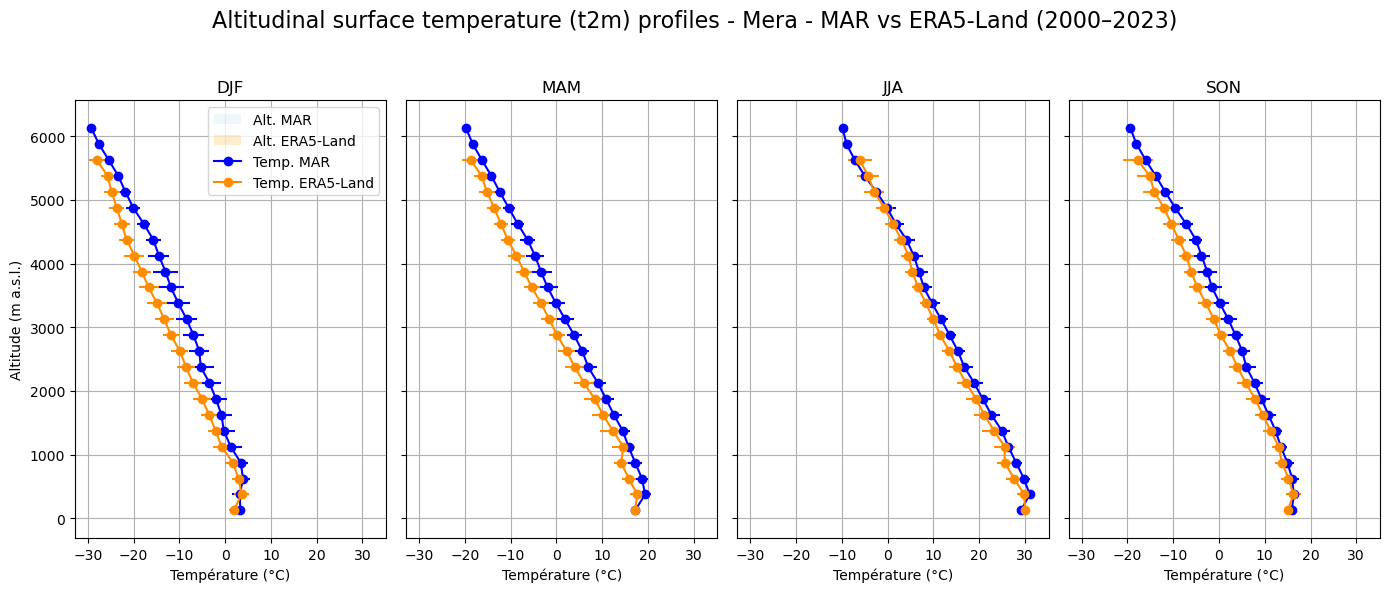

In [15]:
import numpy as np
import matplotlib.pyplot as plt

ncols = 4
fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(14, 6)) 
axs = axs.flatten() 

SH_mar = ds_grF.SH.values.flatten()
SH_era5land = orog_era5land.values.reshape(-1)

for i in range(ncols):
    # Binning altitudes
    alt_min_mar = int(np.floor(SH_mar.min() / 250) * 250)
    alt_max_mar = int(np.ceil(SH_mar.max() / 250) * 250)
    bins_mar = np.arange(alt_min_mar, alt_max_mar + 250, 250)

    alt_min_era5land = int(np.floor(SH_era5land.min() / 250) * 250)
    alt_max_era5land = int(np.ceil(SH_era5land.max() / 250) * 250)
    bins_era5land = np.arange(alt_min_era5land, alt_max_era5land + 250, 250)

    # Températures moyennes saisonnières
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values.reshape(-1)
    temp_era5land = tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[i]).values.reshape(-1)

    # Moyennes par altitude pour MAR
    means_mar, stds_mar, bin_centers_mar = [], [], []
    for j in range(len(bins_mar) - 1):
        mask = (SH_mar >= bins_mar[j]) & (SH_mar < bins_mar[j + 1])
        if np.any(mask):
            means_mar.append(temp_mar[mask].mean())
            stds_mar.append(temp_mar[mask].std())
            bin_centers_mar.append((bins_mar[j] + bins_mar[j + 1]) / 2)

    # Moyennes par altitude pour ERA5-Land
    means_era5land, stds_era5land, bin_centers_era5land = [], [], []
    for k in range(len(bins_era5land) - 1):
        mask = (SH_era5land >= bins_era5land[k]) & (SH_era5land < bins_era5land[k + 1])
        if np.any(mask):
            means_era5land.append(temp_era5land[mask].mean())
            stds_era5land.append(temp_era5land[mask].std())
            bin_centers_era5land.append((bins_era5land[k] + bins_era5land[k + 1]) / 2)

    # Axe de la saison courante
    ax = axs[i]

    # Histogrammes normalisés d'altitude (même axe)
    ax.hist(SH_mar, bins=bins_mar, density=True, orientation='horizontal',
            color='lightblue', alpha=0.2, label='Alt. MAR' if i == 0 else None)
    ax.hist(SH_era5land, bins=bins_era5land, density=True, orientation='horizontal',
            color='orange', alpha=0.2, label='Alt. ERA5-Land' if i == 0 else None)

    # Courbes de température
    ax.errorbar(means_mar, bin_centers_mar, xerr=stds_mar, fmt='o-', color='blue', label='Temp. MAR' if i == 0 else None)
    ax.errorbar(means_era5land, bin_centers_era5land, xerr=stds_era5land, fmt='o-', color='darkorange', label='Temp. ERA5-Land' if i == 0 else None)

    # Mise en forme
    ax.set_title(f"{season_list[i]}")
    ax.set_xlabel("Température (°C)")
    if i == 0:
        ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)

    # Afficher la légende qu'une seule fois
    if i == 0:
        ax.legend()

# Titre principal
fig.suptitle('Altitudinal surface temperature (t2m) profiles - Mera - MAR vs ERA5-Land (2000–2023)', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Alti_profiles_MAR_ERA5-Land_Mera.png", dpi=200, bbox_inches='tight')
plt.show()


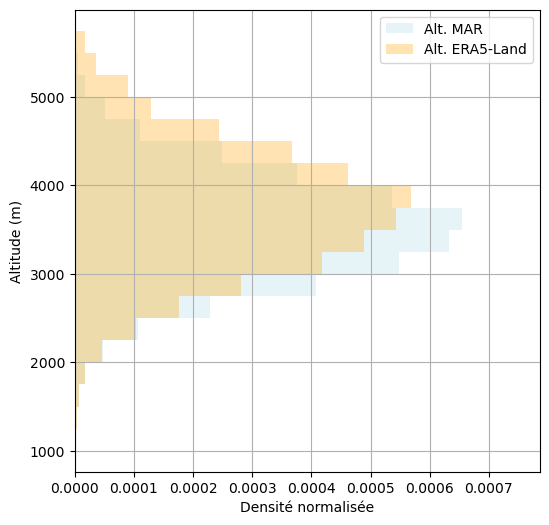

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple de données factices
SH_mar = np.random.normal(loc=3500, scale=600, size=10000)
SH_era5land = np.random.normal(loc=3700, scale=700, size=10000)

bins_mar = np.arange(1000, 6000, 250)
bins_era5land = np.arange(1000, 6000, 250)

# Histogrammes normalisés
hist_mar, _ = np.histogram(SH_mar, bins=bins_mar, density=True)
hist_era5, _ = np.histogram(SH_era5land, bins=bins_era5land, density=True)
dens_max = max(hist_mar.max(), hist_era5.max()) * 1.2

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(SH_mar, bins=bins_mar, density=True, orientation='horizontal',
        color='lightblue', alpha=0.3, label='Alt. MAR')
ax.hist(SH_era5land, bins=bins_era5land, density=True, orientation='horizontal',
        color='orange', alpha=0.3, label='Alt. ERA5-Land')

ax.set_xlim(0, dens_max)
ax.set_ylabel("Altitude (m)")
ax.set_xlabel("Densité normalisée")
ax.legend()
ax.grid(True)
plt.show()


## MAR vs ERA5

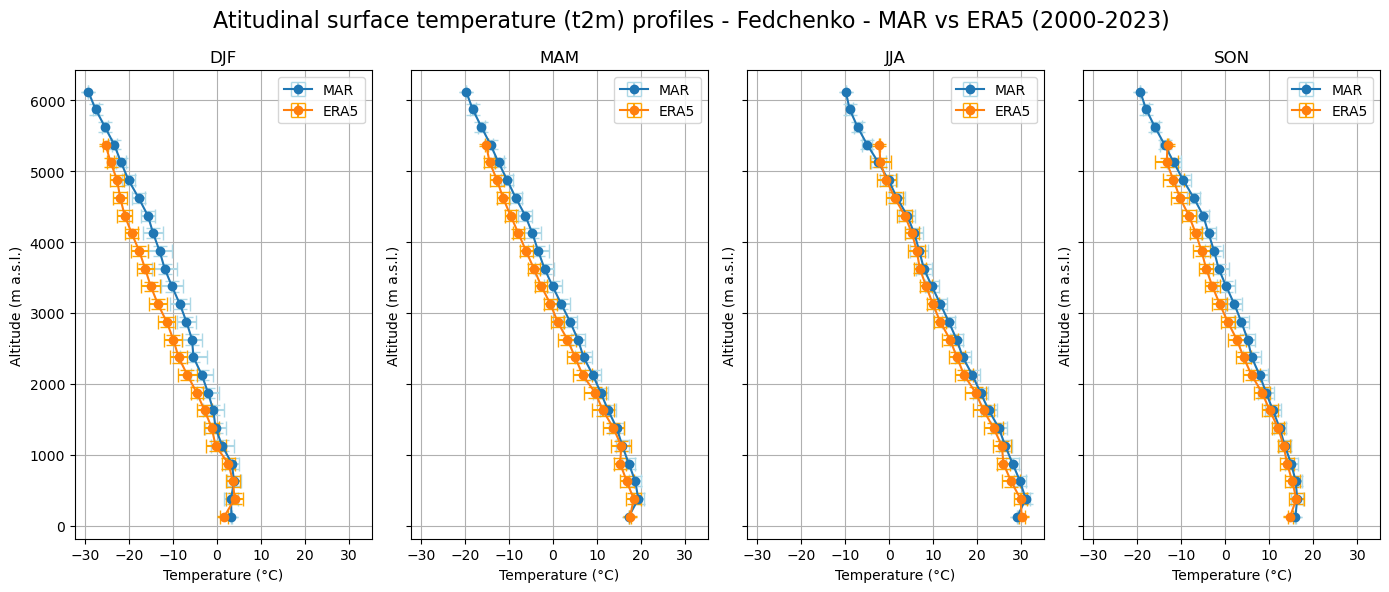

In [13]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(14, 6)) 
axs = axs.flatten() 

SH_mar=ds_grF.SH.values.flatten()
SH_era5=orog_era5.values.reshape(-1)

for i in range(4):
    alt_min_mar = int(np.floor(SH_mar.min() / 250) * 250)
    alt_max_mar = int(np.ceil(SH_mar.max() / 250) * 250) 
    bins_mar = np.arange(alt_min_mar, alt_max_mar + 250, 250)
    means_mar = []
    stds_mar = []
    stds_SHmar = []
    bin_centers_mar = []

    alt_min_era5 = int(np.floor(SH_era5.min() / 250) * 250)
    alt_max_era5 = int(np.ceil(SH_era5.max() / 250) * 250)     
    bins_era5 = np.arange(alt_min_era5, alt_max_era5 + 250, 250)
    means_era5 = []
    stds_era5 = []
    stds_SHera5 = []
    bin_centers_era5 = []
    
    ax = axs[i]
    
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5=tmp_era5.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5_flat = temp_era5.reshape(-1)


    for j in range(len(bins_mar) - 1):
        mask_mar = (SH_mar >= bins_mar[j]) & (SH_mar < bins_mar[j + 1])
        temp_mar_in_bin = temp_mar_flat[mask_mar]
        SH_mar_in_bin = SH_mar[mask_mar]
        
        if len(temp_mar_in_bin) > 0:
            means_mar.append(np.mean(temp_mar_in_bin))
            stds_mar.append(np.std(temp_mar_in_bin))
            stds_SHmar.append(np.std(SH_mar_in_bin))
            bin_centers_mar.append((bins_mar[j] + bins_mar[j + 1]) / 2)

    for k in range(len(bins_era5) - 1):
        mask_era5 = (SH_era5 >= bins_era5[k]) & (SH_era5 < bins_era5[k + 1])
        temp_era5_in_bin = temp_era5_flat[mask_era5]    
        SH_era5_in_bin = SH_era5[mask_era5]
        
        if len(temp_era5_in_bin) > 0:
            means_era5.append(np.mean(temp_era5_in_bin))
            stds_era5.append(np.std( temp_era5_in_bin))
            stds_SHera5.append(np.std(SH_era5_in_bin))
            bin_centers_era5.append((bins_era5[k] + bins_era5[k + 1]) / 2)       
            

    ax.errorbar(means_mar,bin_centers_mar, xerr=stds_mar, yerr=stds_SHmar, fmt='o-', ecolor='lightblue', capsize=5, label ='MAR',)
    ax.errorbar(means_era5,bin_centers_era5, xerr=stds_era5,yerr=stds_SHera5 , fmt='o-', ecolor='orange', capsize=5, label ='ERA5',)
    
    ax.set_title(f"{season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) profiles - Fedchenko - MAR vs ERA5 (2000-2023) ', fontsize=16)

plt.savefig("Alti_profiles_MAR_ERA5_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()